In [11]:
# Import all the libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Make charts look nice
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

print("✅ Libraries imported successfully!")


✅ Libraries imported successfully!


In [12]:
df = pd.read_csv(r'C:\Users\Administrator\Downloads\SALESINSIGHT\Data analyst projects\train.csv', encoding='latin-1')

print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape of dataset: (9800, 18)

First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [13]:
import os
print("Current folder:", os.getcwd())
print("\nFiles in this folder:")
for file in os.listdir():
    print(file)

Current folder: C:\Users\Administrator\anaconda_projects\54ff4165-a589-446a-8e97-261143c20d32

Files in this folder:
.ipynb_checkpoints
superstore_sales_analysis.ipynb


In [14]:
print("=== DATASET INFO ===")
df.info()


=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   

In [15]:
print("=== MISSING VALUES ===")
missing = df.isnull().sum()
print(missing[missing > 0])
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

=== MISSING VALUES ===
Postal Code    11
dtype: int64

Total missing values: 11


In [16]:
print("=== CLEANING DATA ===")

# 1. Fill missing Postal Codes with 0
df['Postal Code'] = df['Postal Code'].fillna(0)

# 2. Convert Order Date and Ship Date to proper date format
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

# 3. Extract useful date parts
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month Name'] = df['Order Date'].dt.strftime('%B')

# 4. Verify cleaning worked
print("Missing values after cleaning:")
print(df.isnull().sum().sum())
print("\nDate columns fixed:")
print(df[['Order Date', 'Ship Date', 'Order Year', 'Order Month']].head())

=== CLEANING DATA ===
Missing values after cleaning:
0

Date columns fixed:
  Order Date  Ship Date  Order Year  Order Month
0 2017-11-08 2017-11-11        2017           11
1 2017-11-08 2017-11-11        2017           11
2 2017-06-12 2017-06-16        2017            6
3 2016-10-11 2016-10-18        2016           10
4 2016-10-11 2016-10-18        2016           10


In [17]:
print("=== BASIC STATISTICS ===")
print("\nNumerical columns summary:")
df.describe()

=== BASIC STATISTICS ===

Numerical columns summary:


,Row ID,Order Date,Ship Date,Postal Code,Sales,Order Year,Order Month
count,9800.000000,9800,9800,9800.000000,9800.000000,9800.000000,9800.000000
mean,4900.500000,2017-05-01 05:13:51.673469440,2017-05-05 04:17:52.653061120,55211.280918,230.769059,2016.724184,7.818469
min,1.000000,2015-01-03 00:00:00,2015-01-07 00:00:00,0.000000,0.444000,2015.000000,1.000000
25%,2450.750000,2016-05-24 00:00:00,2016-05-27 18:00:00,23223.000000,17.248000,2016.000000,5.000000
50%,4900.500000,2017-06-26 00:00:00,2017-06-29 00:00:00,57551.000000,54.490000,2017.000000,9.000000
75%,7350.250000,2018-05-15 00:00:00,2018-05-19 00:00:00,90008.000000,210.605000,2018.000000,11.000000
max,9800.000000,2018-12-30 00:00:00,2019-01-05 00:00:00,99301.000000,22638.480000,2018.000000,12.000000
std,2829.160653,NaN,NaN,32076.677954,626.651875,1.123984,3.281905


In [18]:
print("=== SALES ANALYSIS ===")

# Total Revenue
total_sales = df['Sales'].sum()
print(f"💰 Total Revenue: ${total_sales:,.2f}")

# Average order value
avg_sales = df['Sales'].mean()
print(f"📊 Average Order Value: ${avg_sales:,.2f}")

# Total number of orders
total_orders = df['Order ID'].nunique()
print(f"📦 Total Unique Orders: {total_orders:,}")

# Total customers
total_customers = df['Customer ID'].nunique()
print(f"👥 Total Unique Customers: {total_customers:,}")

=== SALES ANALYSIS ===
💰 Total Revenue: $2,261,536.78
📊 Average Order Value: $230.77
📦 Total Unique Orders: 4,922
👥 Total Unique Customers: 793


In [19]:
print("=== SALES BY CATEGORY ===")

category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(category_sales)
print(f"\nBest Category: {category_sales.index[0]}")
print(f"Revenue: ${category_sales.iloc[0]:,.2f}")

=== SALES BY CATEGORY ===
Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

Best Category: Technology
Revenue: $827,455.87


In [20]:
print("=== SALES BY REGION ===")

region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print(region_sales)
print(f"\nBest Region: {region_sales.index[0]}")
print(f"Worst Region: {region_sales.index[-1]}")

=== SALES BY REGION ===
Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

Best Region: West
Worst Region: South


In [21]:
print("=== SALES BY YEAR ===")

yearly_sales = df.groupby('Order Year')['Sales'].sum()
print(yearly_sales)

# Calculate growth
for i in range(1, len(yearly_sales)):
    growth = ((yearly_sales.iloc[i] - yearly_sales.iloc[i-1]) / yearly_sales.iloc[i-1]) * 100
    print(f"\n{yearly_sales.index[i]} growth vs previous year: {growth:.1f}%")

=== SALES BY YEAR ===
Order Year
2015    479856.2081
2016    459436.0054
2017    600192.5500
2018    722052.0192
Name: Sales, dtype: float64

2016 growth vs previous year: -4.3%

2017 growth vs previous year: 30.6%

2018 growth vs previous year: 20.3%


In [22]:
print("=== TOP 10 CUSTOMERS ===")

top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)
print(top_customers)


=== TOP 10 CUSTOMERS ===
Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


In [23]:
print("=== TOP 10 PRODUCTS ===")

top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
for i, (product, sales) in enumerate(top_products.items(), 1):
    print(f"{i}. {product[:50]}: ${sales:,.2f}")

=== TOP 10 PRODUCTS ===
1. Canon imageCLASS 2200 Advanced Copier: $61,599.82
2. Fellowes PB500 Electric Punch Plastic Comb Binding: $27,453.38
3. Cisco TelePresence System EX90 Videoconferencing U: $22,638.48
4. HON 5400 Series Task Chairs for Big and Tall: $21,870.58
5. GBC DocuBind TL300 Electric Binding System: $19,823.48
6. GBC Ibimaster 500 Manual ProClick Binding System: $19,024.50
7. Hewlett Packard LaserJet 3310 Copier: $18,839.69
8. HP Designjet T520 Inkjet Large Format Printer - 24: $18,374.90
9. GBC DocuBind P400 Electric Binding System: $17,965.07
10. High Speed Automatic Electric Letter Opener: $17,030.31


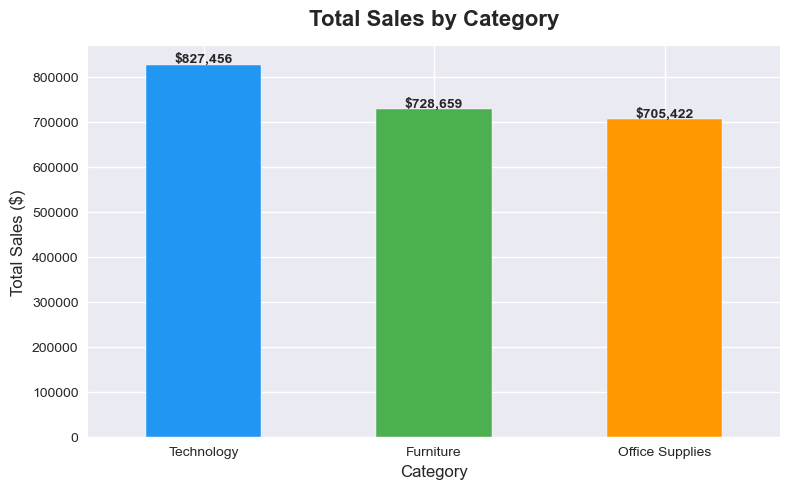

✅ Chart 1 done!


In [24]:
# ===  VISUALIZATION 1 — Sales by Category ===
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#2196F3', '#4CAF50', '#FF9800']
category_sales.plot(kind='bar', ax=ax, color=colors, edgecolor='white')

ax.set_title('Total Sales by Category', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Total Sales ($)', fontsize=12)
ax.tick_params(axis='x', rotation=0)

# Add value labels on bars
for i, v in enumerate(category_sales):
    ax.text(i, v + 5000, f'${v:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
print("✅ Chart 1 done!")

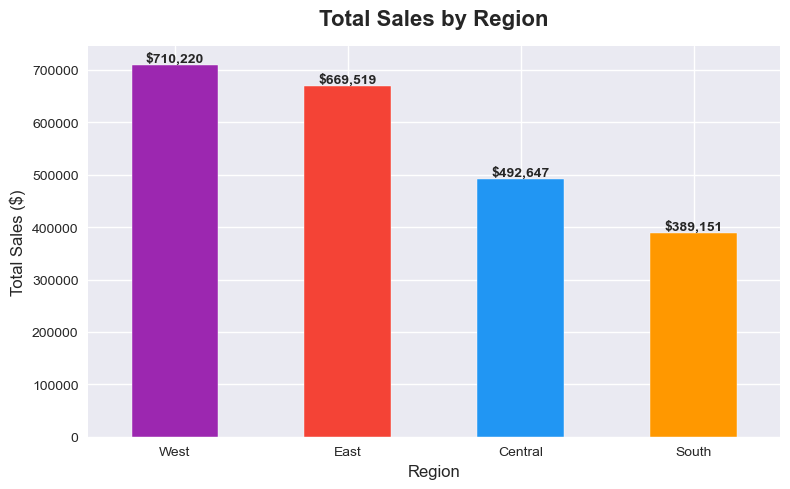

✅ Chart 2 done!


In [25]:
# === VISUALIZATION 2 — Sales by Region ===
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#9C27B0', '#F44336', '#2196F3', '#FF9800']
region_sales.plot(kind='bar', ax=ax, color=colors, edgecolor='white')

ax.set_title('Total Sales by Region', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Region', fontsize=12)
ax.set_ylabel('Total Sales ($)', fontsize=12)
ax.tick_params(axis='x', rotation=0)

for i, v in enumerate(region_sales):
    ax.text(i, v + 5000, f'${v:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
print("✅ Chart 2 done!")

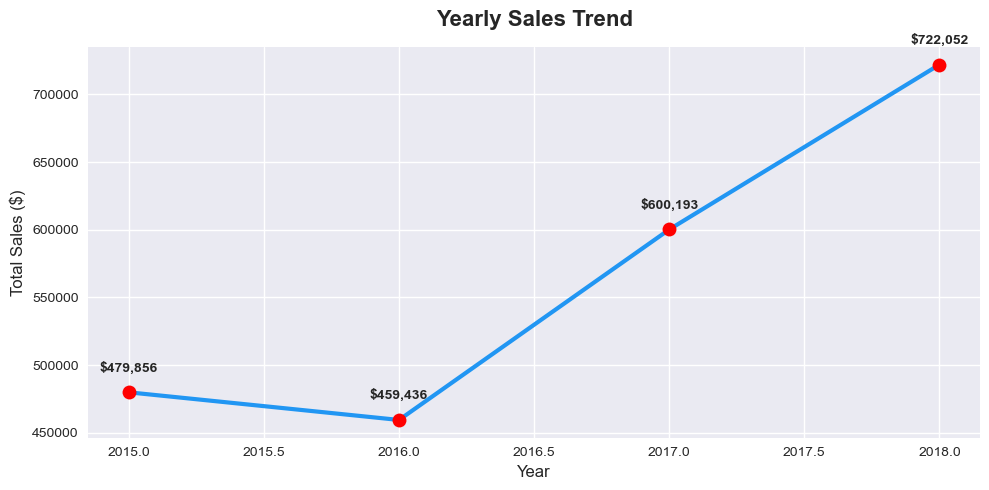

✅ Chart 3 done!


In [26]:
# === VISUALIZATION 3 — Yearly Sales Trend ===
fig, ax = plt.subplots(figsize=(10, 5))

yearly_sales.plot(kind='line', ax=ax, 
                  color='#2196F3', 
                  linewidth=3, 
                  marker='o', 
                  markersize=10,
                  markerfacecolor='red')

ax.set_title('Yearly Sales Trend', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Total Sales ($)', fontsize=12)

for x, y in yearly_sales.items():
    ax.annotate(f'${y:,.0f}', (x, y), 
                textcoords="offset points", 
                xytext=(0, 15), 
                ha='center', 
                fontweight='bold')

plt.tight_layout()
plt.show()
print("✅ Chart 3 done!")

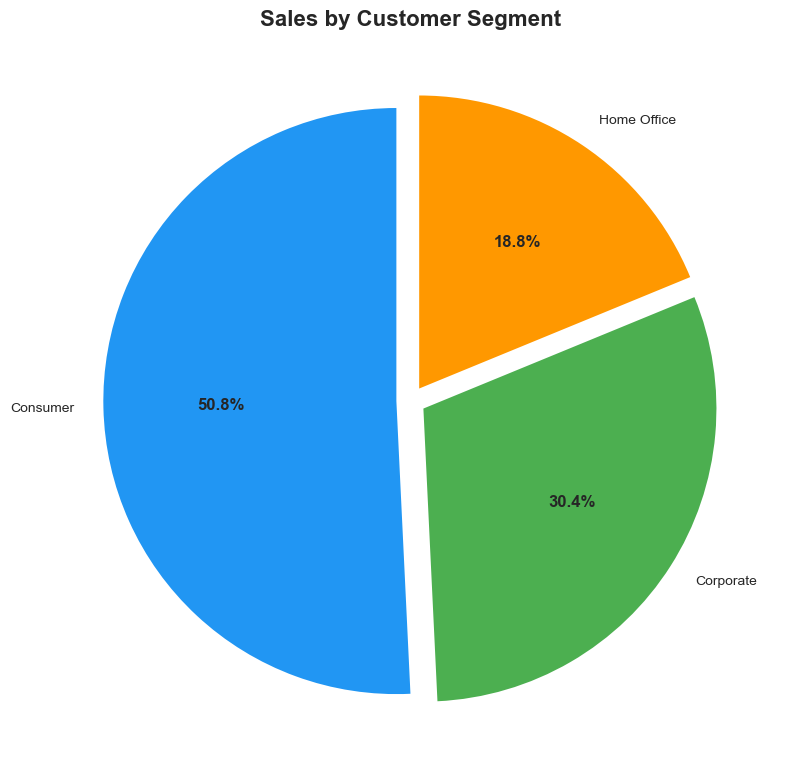

✅ Chart 4 done!


In [27]:
# === VISUALIZATION 4 — Sales by Segment ===
fig, ax = plt.subplots(figsize=(8, 8))

segment_sales = df.groupby('Segment')['Sales'].sum()

colors = ['#2196F3', '#4CAF50', '#FF9800']
wedges, texts, autotexts = ax.pie(
    segment_sales,
    labels=segment_sales.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    explode=(0.05, 0.05, 0.05)
)

for text in autotexts:
    text.set_fontsize(12)
    text.set_fontweight('bold')

ax.set_title('Sales by Customer Segment', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Chart 4 done!")

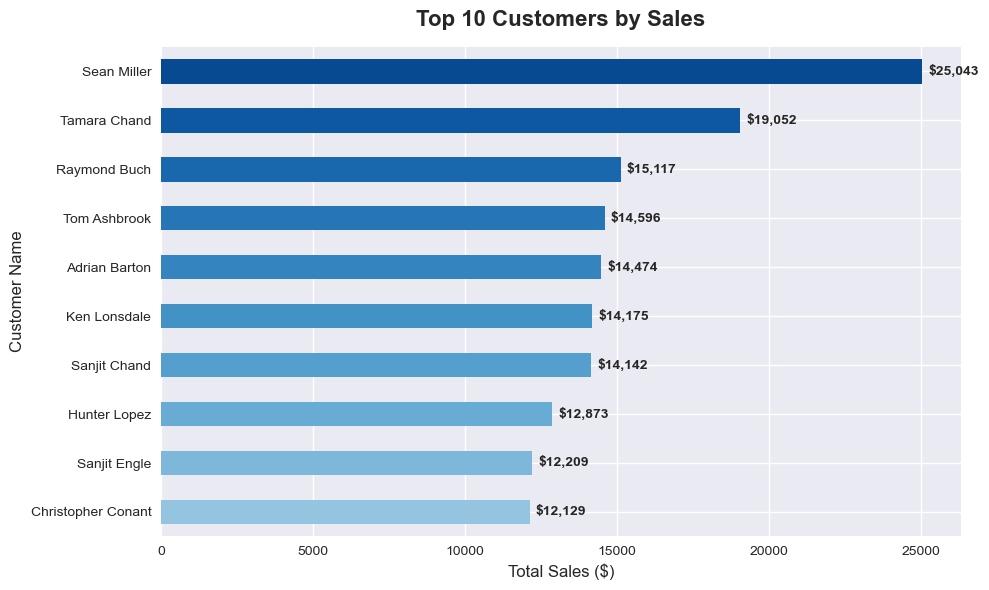

✅ Chart 5 done!


In [28]:
# === VISUALIZATION 5 — Top 10 Customers ===
fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.cm.Blues(np.linspace(0.4, 0.9, 10))
top_customers.sort_values().plot(kind='barh', ax=ax, color=colors)

ax.set_title('Top 10 Customers by Sales', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Total Sales ($)', fontsize=12)
ax.set_ylabel('Customer Name', fontsize=12)

for i, v in enumerate(top_customers.sort_values()):
    ax.text(v + 200, i, f'${v:,.0f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()
print("✅ Chart 5 done!")

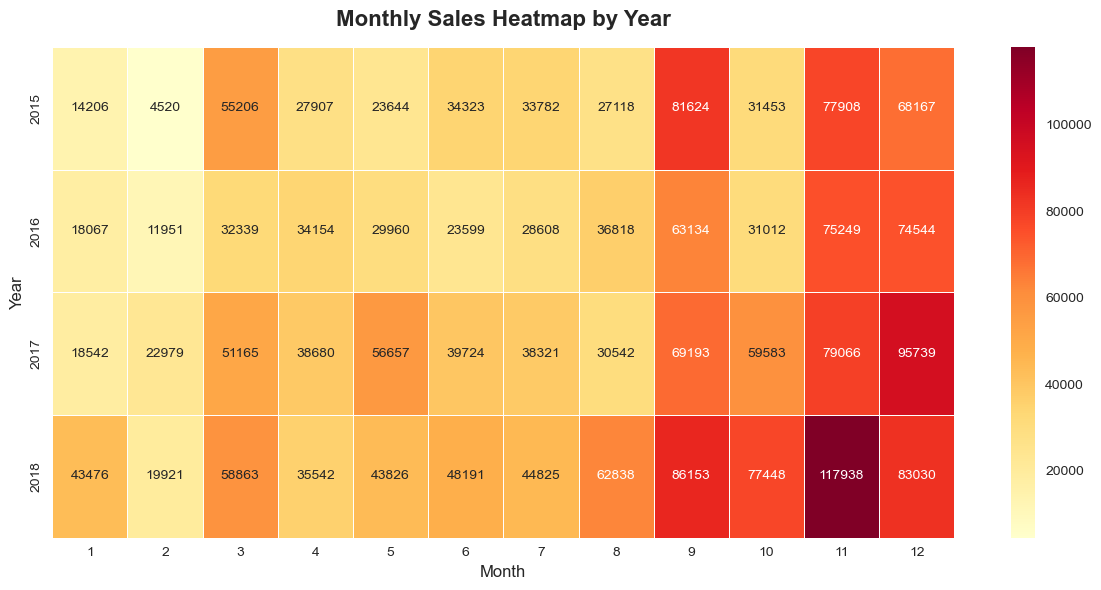

✅ Chart 6 done!


In [29]:
# === VISUALIZATION 6 — Monthly Sales Heatmap ===
fig, ax = plt.subplots(figsize=(12, 6))

monthly_sales = df.groupby(['Order Year', 'Order Month'])['Sales'].sum().unstack()

sns.heatmap(monthly_sales, 
            annot=True, 
            fmt='.0f',
            cmap='YlOrRd',
            ax=ax,
            linewidths=0.5)

ax.set_title('Monthly Sales Heatmap by Year', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Year', fontsize=12)

plt.tight_layout()
plt.show()
print("✅ Chart 6 done!")

In [30]:
# === FINAL INSIGHTS & CONCLUSIONS ===
print("=" * 50)
print("   SUPERSTORE SALES ANALYSIS - KEY FINDINGS")
print("=" * 50)

print(f"""
📊 OVERVIEW:
   • Total Revenue: $2,261,536.78
   • Total Orders: 4,922
   • Total Customers: 793
   • Data Period: 2015-2018

🏆 TOP PERFORMERS:
   • Best Category: Technology ($827,456)
   • Best Region: West ($710,220)
   • Best Customer: Sean Miller ($25,043)
   • Best Product: Canon imageCLASS Copier ($61,600)
   • Best Month: November 2018 ($117,938)

📈 GROWTH TRENDS:
   • 2016: -4.3% (difficult year)
   • 2017: +30.6% (strong recovery!)
   • 2018: +20.3% (continued growth)
   • Overall: +50% growth from 2015 to 2018

⚠️ AREAS OF CONCERN:
   • South region underperforming ($389,151)
   • February always slowest month
   • Home Office segment only 18.8% of sales

✅ RECOMMENDATIONS:
   1. Increase marketing in South region
   2. Launch promotions in January/February
   3. Create VIP program for top 10 customers
   4. Stock more Technology products
   5. Target Consumer segment (50.8% of revenue)
""")
print("=" * 50)
print("✅ Analysis Complete!")

   SUPERSTORE SALES ANALYSIS - KEY FINDINGS

📊 OVERVIEW:
   • Total Revenue: $2,261,536.78
   • Total Orders: 4,922
   • Total Customers: 793
   • Data Period: 2015-2018

🏆 TOP PERFORMERS:
   • Best Category: Technology ($827,456)
   • Best Region: West ($710,220)
   • Best Customer: Sean Miller ($25,043)
   • Best Product: Canon imageCLASS Copier ($61,600)
   • Best Month: November 2018 ($117,938)

📈 GROWTH TRENDS:
   • 2016: -4.3% (difficult year)
   • 2017: +30.6% (strong recovery!)
   • 2018: +20.3% (continued growth)
   • Overall: +50% growth from 2015 to 2018

⚠️ AREAS OF CONCERN:
   • South region underperforming ($389,151)
   • February always slowest month
   • Home Office segment only 18.8% of sales

✅ RECOMMENDATIONS:
   1. Increase marketing in South region
   2. Launch promotions in January/February
   3. Create VIP program for top 10 customers
   4. Stock more Technology products
   5. Target Consumer segment (50.8% of revenue)

✅ Analysis Complete!
